# GradCAM++ dla RF-DETR (implementacja własna)

Gradient-based saliency na poziomie detekcji; własna implementacja bez `pytorch-grad-cam`.

**Schemat działania:**

```
predict() detekcja  →  IoU match do raw query
  →  target_score = raw_logit[query_id, class_id]
  →  backward
  →  GradCAM++ z C2f.cv2 (ostatnia warstwa projektora — ta sama co EigenCAM)
```

**Matematyka GradCAM++ (arXiv:1710.11063):**
$$\alpha_{ij}^k = \frac{(\partial^2 S)^2}{2(\partial^2 S)^2 + \sum_{ij} A_{ij}^k (\partial^3 S)}$$
$$w^k = \sum_{ij} \alpha_{ij}^k \cdot \text{ReLU}\!\left(\frac{\partial S}{\partial A_{ij}^k}\right)$$
$$\text{CAM} = \text{ReLU}\!\left(\sum_k w^k A^k\right)$$

Implementacja w `src/rfdetr_gradcampp_custom.py`.

**Interpretacja wyników:** Wysokie `matched_iou` (query ↔ detekcja) nie gwarantuje sensownej mapy GradCAM++ — ViT + DETR mogą dawać słabą lokalizację gradientową na wybranej warstwie projektora. Niskie *Pointing game* / *energy fraction* przy IoU ≈ 1 oznaczają raczej **słaby kandydat warstwy lub metody**, nie błąd dopasowania query. W takim przypadku raportuj wynik negatywny, zrób **sweep warstw** (poniżej) i porównaj z EigenCAM / D-RISE / mapami uwagi.

In [21]:
from pathlib import Path
import os
import sys
import site

def find_repo_root(marker="pyproject.toml", max_depth=10):
    current = Path.cwd().resolve()
    for _ in range(max_depth):
        if (current / marker).exists():
            return current
        current = current.parent
    return None

def prefer_venv_site_packages():
    venv_prefix = str(Path(sys.prefix).resolve())
    venv_sites = [p for p in site.getsitepackages() if p.startswith(venv_prefix)]
    cleaned = [p for p in sys.path if not (p.startswith("/net/software/") and "site-packages" in p)]
    for p in reversed(venv_sites):
        if p in cleaned:
            cleaned.remove(p)
        cleaned.insert(0, p)
    sys.path[:] = cleaned
    cached = sys.modules.get("regex")
    cached_path = getattr(cached, "__file__", "") if cached is not None else ""
    if cached_path.startswith("/net/software/"):
        for name in list(sys.modules.keys()):
            if name == "regex" or name.startswith("regex."):
                del sys.modules[name]

REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = Path("/net/tscratch/people/plgbmruszaj/dermatoscopy_ai")

RFD_XAI_ROOT = REPO_ROOT / "dermato_ai" / "rfdetr-xai"
os.chdir(RFD_XAI_ROOT)
sys.path.insert(0, str(RFD_XAI_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT))
prefer_venv_site_packages()

from dermato_ai.coco.dataset_manager import COCODatasetManager

DATA_ZIP_DIR = REPO_ROOT / "data" / "coco_images_zip"
manager = COCODatasetManager.from_archive(directory=DATA_ZIP_DIR, archive_pattern="*.zip")
dataset_dir = Path(manager.json_path).parent
dedup_coco_json = dataset_dir / "result_dedup_for_gradcampp.json"
manager.save(str(dedup_coco_json))

COCO_JSON = str(dedup_coco_json)
IMAGES_DIR = str(dataset_dir / "images")

CHECKPOINT = "/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth"
OUTPUT_DIR = RFD_XAI_ROOT / "wyniki" / "rfdetr_gradcampp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Python:", sys.executable)
print("✓ COCO JSON:", COCO_JSON)
print("✓ Images:", IMAGES_DIR)
print("✓ Checkpoint:", CHECKPOINT)
print("✓ Output dir:", OUTPUT_DIR)

INFO: Found newest archive: project-5-at-2026-05-07-11-56-9b7fa76c.zip
INFO: Unpacking project-5-at-2026-05-07-11-56-9b7fa76c.zip to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted


INFO: Extraction complete
INFO: Found result.json at: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loading COCO dataset from /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loaded 314 images, 1299 annotations
INFO: Collapsed duplicate image passes: removed 97 image entries and 0 annotations
INFO: Valid COCO structure: 217 images, 1299 annotations, 10 categories
INFO: Fixed 217 image paths
INFO: Saved dataset to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_gradcampp.json


✓ Python: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/.venv/bin/python
✓ COCO JSON: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_gradcampp.json
✓ Images: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images
✓ Checkpoint: /net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth
✓ Output dir: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_gradcampp


## Konfiguracja

In [22]:
THRESHOLD     = 0.25   # próg detekcji dla predict()
MIN_MATCH_IOU = 0.3    # minimalny IoU query↔detection; niższy → skip
CLASS_AWARE   = True   # wymagaj zgodności klasy przy dopasowaniu query
CAM_ALPHA     = 0.45   # przezroczystość overlay

# Cel backward: "logit" (standard) | "sigmoid_logit" (inny rozkład gradientu)
TARGET_MODE = "logit"

# Po sweepie (najwyższy mean_energy_fraction): wyjście całego pierwszego stage (Sequential).
# None → default_target_layer_name() (kanonicznie: backbone.0.projector.stages.0.0.cv2).
GRADCAM_TARGET_LAYER_NAME = "backbone.0.projector.stages.0"

# Indeks obrazu w posortowanej liście (zmień, by zobaczyć inny obraz)
IMAGE_IDX = 0

## Ładowanie modelu i obrazu

In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from rfdetr_load import load_rfdetr
from rfdetr_gradcampp_custom import (
    cam_quality_status,
    run_gradcampp_for_detection,
    make_gradcampp_figure,
    save_gradcampp_result,
    overlay_cam_on_image,
    resolve_rfdetr_device,
    inspect_candidate_cam_layers,
    default_target_layer_name,
    get_module_by_name,
    draw_box_on_heatmap,
    DEFAULT_CAM_TARGET_LAYER_NAME,
)
from xai_metrics import (
    pointing_game_hit,
    energy_fraction_inside_bbox,
    energy_enrichment_inside_bbox,
)

try:
    from IPython.display import display
except ImportError:
    display = print

model = load_rfdetr("large", CHECKPOINT)

all_images = sorted(Path(IMAGES_DIR).glob("*"))
image_path = all_images[IMAGE_IDX]
pil_img = Image.open(image_path).convert("RGB")
image_rgb = np.array(pil_img)

print(f"✓ Model załadowany")
print(f"✓ Obraz: {image_path.name}  ({pil_img.width}×{pil_img.height} px)")

[2026-05-08 09:24:09] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-08 09:24:09] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-08 09:24:10] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


✓ Model załadowany
✓ Obraz: 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg  (1920×1080 px)


## Weryfikacja warstwy docelowej

Ta sama warstwa co EigenCAM: `C2f.cv2` z ostatniego etapu `MultiScaleProjector`.

> **Uwaga dot. device:** `rfdetr_api.model.device` jest atrybutem konfiguracyjnym i może
> nie zgadzać się z faktycznym urządzeniem parametrów modelu (np. backbone DINOv2 ładuje się
> na CPU przez HuggingFace Transformers). `resolve_rfdetr_device` pobiera urządzenie z
> `next(inner.parameters()).device` — to jedyne wiarygodne źródło.

In [24]:
import torch
from rfdetr_gradcampp_custom import preprocess_for_gradcampp

# Ta sama warstwa co domyślny GradCAM++ / EigenCAM (kanoniczna ścieżka lub fallback)
inner = model.model.model
_layer_name = default_target_layer_name(inner)
target_layer = get_module_by_name(inner, _layer_name)

# Rzeczywiste urządzenie modelu (z parametrów, nie z .device)
device = resolve_rfdetr_device(model)
batch, orig_hw, input_hw = preprocess_for_gradcampp(model, pil_img)

print("✓ Warstwa docelowa:", target_layer.__class__.__name__, "|", _layer_name)
print(f"✓ Urządzenie modelu (z parametrów): {device}")
print(f"✓ Batch device: {batch.device}  dtype: {batch.dtype}")
print(f"✓ orig_hw={orig_hw}  input_hw={input_hw}")

# Probe: kształt aktywacji z warstwy docelowej
captured = []

def _probe_hook(module, inputs, output):
    t = output if isinstance(output, torch.Tensor) else (output[0] if isinstance(output, (list, tuple)) else None)
    if t is not None:
        captured.append(tuple(t.shape))

handle = target_layer.register_forward_hook(_probe_hook)
try:
    with torch.no_grad():
        _ = inner(batch)
finally:
    handle.remove()

if captured:
    print(f"✓ Kształt aktywacji warstwy: {captured[0]}")
else:
    print("⚠ Hook nie przechwycił aktywacji")

✓ Warstwa docelowa: ConvX | backbone.0.projector.stages.0.0.cv2
✓ Urządzenie modelu (z parametrów): cpu
✓ Batch device: cpu  dtype: torch.float32
✓ orig_hw=(1080, 1920)  input_hw=(704, 704)
✓ Kształt aktywacji warstwy: (1, 256, 44, 44)


### Kandydaci warstw CAM (do sweepu)

`inspect_candidate_cam_layers` domyślnie zwraca wyłącznie wyjścia **4D** `[B, C, H, W]` (naturalna mapa przestrzenna). Tokenowe tensory 3D z DINO (np. `(4, 485, 384)`) są pomijane — unikasz setek wpisów i konieczności `reshape_transform` jak w ViT.

Baseline: **`DEFAULT_CAM_TARGET_LAYER_NAME`** (pierwszy `C2f.cv2` projektora); `default_target_layer_name(inner)` potwierdza nazwę w grafie lub ustala fallback. Wybrane nazwy wklej do `CANDIDATE_LAYER_NAMES` w sweepie.

Alias: `inspect_cam_candidate_layers` — to samo.

In [25]:
inner = model.model.model
print("Kanoniczna warstwa CAM (baseline):", DEFAULT_CAM_TARGET_LAYER_NAME)
DEFAULT_CAM_LAYER_NAME = default_target_layer_name(inner)
print("Rozwiązana domyślna nazwa w tym modelu:", DEFAULT_CAM_LAYER_NAME)

candidates = inspect_candidate_cam_layers(model, pil_img)  # tylko [B,C,H,W]; keywords: backbone/projector/proj/encoder
print(f"\nLiczba kandydatów 4D: {len(candidates)}\n")
for name, cls_name, shape in sorted(candidates, key=lambda x: x[0])[:80]:
    print(f"  {name:85s} | {cls_name:28s} | {shape}")
if len(candidates) > 80:
    print(f"  ... i {len(candidates) - 80} więcej")

Kanoniczna warstwa CAM (baseline): backbone.0.projector.stages.0.0.cv2
Rozwiązana domyślna nazwa w tym modelu: backbone.0.projector.stages.0.0.cv2

Liczba kandydatów 4D: 48

  backbone                                                                              | Joiner                       | (1, 256, 44, 44)
  backbone.0.encoder                                                                    | DinoV2                       | (1, 384, 44, 44)
  backbone.0.encoder.encoder                                                            | WindowedDinov2WithRegistersBackbone | (1, 384, 44, 44)
  backbone.0.encoder.encoder.embeddings.patch_embeddings.projection                     | Conv2d                       | (1, 384, 44, 44)
  backbone.0.projector                                                                  | MultiScaleProjector          | (1, 256, 44, 44)
  backbone.0.projector.stages.0                                                         | Sequential                   | (1, 256,

## Detekcje z predict()

In [26]:
det = model.predict(pil_img, threshold=THRESHOLD)

if det is None or len(det) == 0:
    print(f"⚠ Brak detekcji (threshold={THRESHOLD}). Zmień IMAGE_IDX lub obniż THRESHOLD.")
else:
    print(f"✓ Znaleziono {len(det)} detekcji:")
    for i in range(len(det)):
        cls_id = int(det.class_id[i])
        conf   = float(det.confidence[i])
        box    = [round(v, 1) for v in det.xyxy[i].tolist()]
        print(f"  det={i}  class_id={cls_id}  conf={conf:.4f}  box={box}")

[2026-05-08 09:24:11] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


✓ Znaleziono 4 detekcji:
  det=0  class_id=0  conf=0.8513  box=[861.7, 713.1, 922.8, 812.9]
  det=1  class_id=0  conf=0.8155  box=[554.0, 488.9, 625.1, 652.4]
  det=2  class_id=0  conf=0.7669  box=[679.9, 821.2, 793.5, 875.2]
  det=3  class_id=0  conf=0.7176  box=[496.8, 800.7, 539.1, 896.9]


## GradCAM++ dla pierwszej detekcji

In [27]:
assert det is not None and len(det) > 0, "Brak detekcji — zatrzymaj wykonanie."

DET_IDX = 0

cam, match = run_gradcampp_for_detection(
    rfdetr_api=model,
    pil_image=pil_img,
    pred_detections=det,
    det_idx=DET_IDX,
    min_match_iou=MIN_MATCH_IOU,
    class_aware=CLASS_AWARE,
    target_layer_name=GRADCAM_TARGET_LAYER_NAME,
    target_mode=TARGET_MODE,
)

class_id   = match["pred_class_id"]
class_name = str(class_id)

print("Match info:")
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in match.items()}, indent=2))
print(f"\nCAM shape: {cam.shape}  min={cam.min():.4f}  max={cam.max():.4f}")

Match info:
{
  "det_idx": 0,
  "query_id": 0,
  "matched_iou": 0.9993,
  "pred_class_id": 0,
  "logit_class_id": 0,
  "pred_confidence": 0.8513,
  "raw_query_class_score": 0.8522,
  "box_orig_xyxy": [
    861.7444458007812,
    713.0776977539062,
    922.7802734375,
    812.891357421875
  ],
  "box_input_xyxy": [
    315.97296142578125,
    464.8210144042969,
    338.3527526855469,
    529.884765625
  ],
  "target_layer_name": "backbone.0.projector.stages.0.0.cv2",
  "target_mode": "logit"
}

CAM shape: (1080, 1920)  min=0.0000  max=1.0000


## Wizualizacja

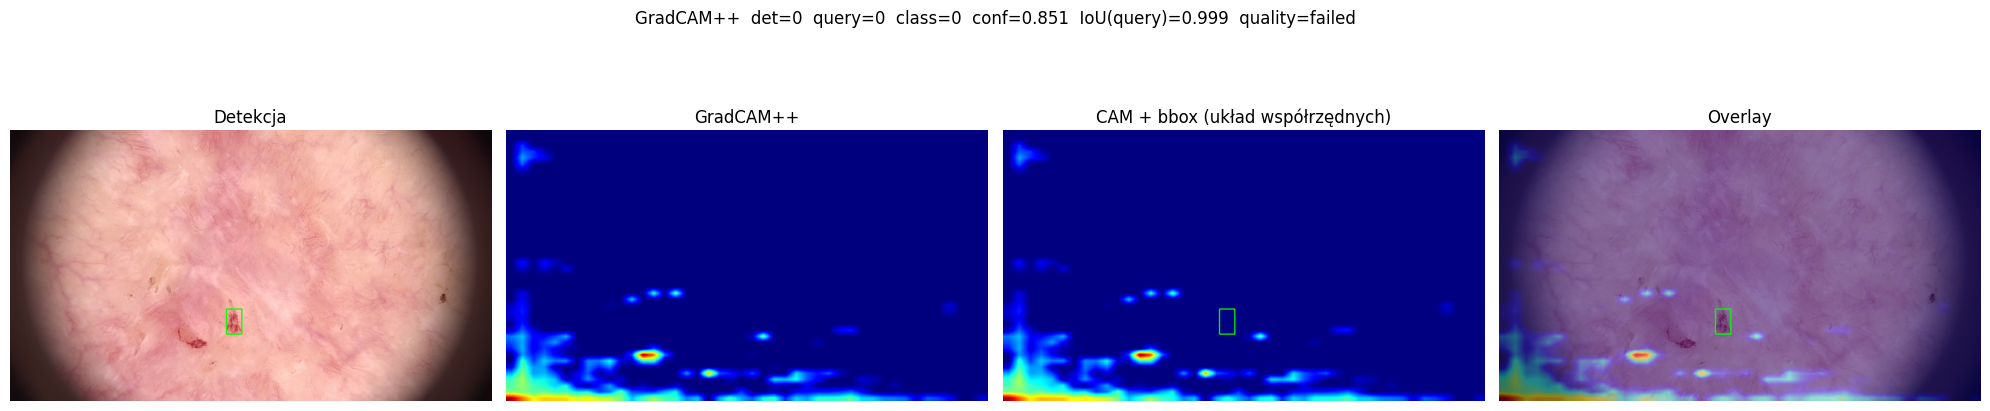

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_gradcampp/gradcampp_img0_det0_q0.png


In [28]:
box_xyxy = tuple(match["box_orig_xyxy"])
hit_preview = pointing_game_hit(cam, box_xyxy)
ef_preview = energy_fraction_inside_bbox(cam, box_xyxy)
qual = cam_quality_status(hit_preview, ef_preview)

fig = make_gradcampp_figure(image_rgb, cam, match, class_name, cam_quality=qual)
plt.show()

stem = f"gradcampp_img{IMAGE_IDX}_det{DET_IDX}_q{match['query_id']}"
png_path = save_gradcampp_result(
    image_rgb=image_rgb,
    cam=cam,
    match=match,
    class_name=class_name,
    out_dir=OUTPUT_DIR,
    stem=stem,
    cam_quality=qual,
    extra_meta={
        "threshold": THRESHOLD,
        "min_match_iou": MIN_MATCH_IOU,
        "image": image_path.name,
        "cam_quality": qual,
        "pointing_game": bool(hit_preview),
        "energy_fraction": float(ef_preview),
    },
)
print(f"✓ Zapisano: {png_path}")

## Metryki dla jednej detekcji

- **Pointing game** — czy szczyt mapy saliencji leży w bbox detekcji?
- **Energy fraction (EF)** — jaki ułamek energii mapy saliencji zawiera bbox?
- **Energy enrichment (EE)** — EF / (box_area / image_area); ≈1 → losowa, >1 → mapa preferuje box, <1 → omija. Uczciwsze niż samo EF bo nie karze za małe boxy.

In [29]:
box_xyxy = tuple(match["box_orig_xyxy"])

hit      = pointing_game_hit(cam, box_xyxy)
ef       = energy_fraction_inside_bbox(cam, box_xyxy)
ee       = energy_enrichment_inside_bbox(cam, box_xyxy)
qual     = cam_quality_status(hit, ef)

print(f"Pointing game hit  : {hit}")
print(f"Energy fraction    : {ef:.4f}")
print(f"Energy enrichment  : {ee:.4f}  (baseline=1.0; >1→focuses on box, <1→avoids box)")
print(f"CAM quality label  : {qual}  (good / weak / failed — heurystyka)")
print(f"Matched IoU        : {match['matched_iou']:.4f}")
print(f"Query class score  : {match['raw_query_class_score']:.4f}")

Pointing game hit  : False
Energy fraction    : 0.0000
Energy enrichment  : 0.0000  (baseline=1.0; >1→focuses on box, <1→avoids box)
CAM quality label  : failed  (good / weak / failed — heurystyka)
Matched IoU        : 0.9993
Query class score  : 0.8522


## Porównanie warstw CAM (wizualizacja)

Trzy nazwy z dyskusji: kanoniczny **`cv2`** (`DEFAULT_CAM_TARGET_LAYER_NAME`), pierwszy stage **`stages.0`**, cały **`projector`**. Dla każdej warstwy: ten sam `DET_IDX`, osobna figura i zapis PNG z sufiksem warstwy.

Uruchom po sekcji **GradCAM++ dla pierwszej detekcji** (wymaga `det`, `DET_IDX`, modelu i obrazu).

In [ ]:
# Warstwy z dyskusji: baseline kodu (cv2) | stages.0 (sweep EF) | cały projector
COMPARE_GRADCAM_LAYERS = [
    "backbone.0.projector.stages.0.0.cv2",
    "backbone.0.projector.stages.0",
    "backbone.0.projector",
]

assert det is not None and len(det) > 0, "Najpierw uruchom sekcję z predict() i detekcją."
assert 0 <= DET_IDX < len(det), "Zły DET_IDX."

results_layer_compare = []
for layer_name in COMPARE_GRADCAM_LAYERS:
    try:
        cam_c, match_c = run_gradcampp_for_detection(
            rfdetr_api=model,
            pil_image=pil_img,
            pred_detections=det,
            det_idx=DET_IDX,
            min_match_iou=MIN_MATCH_IOU,
            class_aware=CLASS_AWARE,
            target_layer_name=layer_name,
            target_mode=TARGET_MODE,
        )
    except Exception as e:
        print(f"⚠ Pomiń {layer_name!r}: {e}")
        continue

    box_xyxy = tuple(match_c["box_orig_xyxy"])
    hit_c = pointing_game_hit(cam_c, box_xyxy)
    ef_c = energy_fraction_inside_bbox(cam_c, box_xyxy)
    qual_c = cam_quality_status(hit_c, ef_c)
    class_name_c = str(match_c["pred_class_id"])

    fig = make_gradcampp_figure(image_rgb, cam_c, match_c, class_name_c, cam_quality=qual_c)
    prev_sup = fig._suptitle.get_text() if getattr(fig, "_suptitle", None) and fig._suptitle else ""
    fig.suptitle(f"{layer_name}\n{prev_sup}", fontsize=9)
    plt.tight_layout()
    plt.show()

    layer_tag = layer_name.replace(".", "_")
    stem = f"gradcampp_compare_img{IMAGE_IDX}_det{DET_IDX}_{layer_tag}_q{match_c['query_id']}"
    png_path = save_gradcampp_result(
        image_rgb=image_rgb,
        cam=cam_c,
        match=match_c,
        class_name=class_name_c,
        out_dir=OUTPUT_DIR,
        stem=stem,
        cam_quality=qual_c,
        extra_meta={
            "compare_layer": layer_name,
            "threshold": THRESHOLD,
            "min_match_iou": MIN_MATCH_IOU,
            "image": image_path.name,
            "pointing_game": bool(hit_c),
            "energy_fraction": float(ef_c),
        },
    )
    print(f"✓ {layer_name}  EF={ef_c:.4f}  pointing_game={hit_c}  quality={qual_c}")
    print(f"  zapis: {png_path}\n")
    results_layer_compare.append(
        {"layer": layer_name, "energy_fraction": ef_c, "pointing_game": hit_c, "quality": qual_c}
    )

if results_layer_compare:
    import pandas as pd

    display(pd.DataFrame(results_layer_compare))

## Sweep warstw (opcjonalnie)

Jeśli GradCAM++ ma dobre `matched_iou`, ale złe `energy_fraction` / *Pointing game*, testuj kilka warstw z listy kandydatów. Wybierz warstwę z najwyższą średnią `mean_energy_fraction` (i/lub `pointing_game_acc`), ustaw `GRADCAM_TARGET_LAYER_NAME` w konfiguracji i uruchom ponownie od detekcji.

Opcjonalnie porównaj **EigenCAM** na tej samej warstwie (`rfdetr_gradcam.run_cam_and_save`) — jeśli EigenCAM jest sensowny, a GradCAM++ nie, problem leży po stronie gradientów/targetu.

In [30]:
def collect_4d_cam_candidate_layers(
    model_core,
    batch,
    include_keywords=("backbone", "projector", "proj", "encoder"),
    prefer_keywords=("projector", "proj"),
):
    """
    Zwraca nazwy warstw z wyjściem 4D [B, C, H, W].
    Najpierw preferuje projector/proj, potem backbone/encoder.
    """
    records = []
    handles = []
    seen = set()

    def extract_first_tensor(output):
        if torch.is_tensor(output):
            return output

        if isinstance(output, (list, tuple)):
            for item in output:
                tensor = extract_first_tensor(item)
                if tensor is not None:
                    return tensor

        if isinstance(output, dict):
            for item in output.values():
                tensor = extract_first_tensor(item)
                if tensor is not None:
                    return tensor

        return None

    def make_hook(name, module):
        def hook(_module, _inputs, output):
            tensor = extract_first_tensor(output)
            if tensor is None:
                return

            shape = tuple(tensor.shape)

            if len(shape) != 4:
                return

            key = (name, shape)
            if key in seen:
                return
            seen.add(key)

            records.append({
                "name": name,
                "module": module.__class__.__name__,
                "shape": shape,
                "is_preferred": any(k in name.lower() for k in prefer_keywords),
            })

        return hook

    for name, module in model_core.named_modules():
        lower = name.lower()

        if not any(k in lower for k in include_keywords):
            continue

        handles.append(module.register_forward_hook(make_hook(name, module)))

    model_core.eval()
    dev = next(model_core.parameters()).device
    x = batch.to(dev)
    with torch.no_grad():
        _ = model_core(x)

    for handle in handles:
        handle.remove()

    # projector/proj na górę, potem reszta
    records = sorted(
        records,
        key=lambda r: (
            not r["is_preferred"],
            r["name"],
        )
    )

    return records


cam_layer_records = collect_4d_cam_candidate_layers(
    model_core=model.model.model,
    batch=batch,
)

print("Znalezione 4D CAM candidate layers:")
for r in cam_layer_records:
    print(f"{r['name']:90s} | {r['module']:30s} | {r['shape']}")

Znalezione 4D CAM candidate layers:
backbone.0.encoder.encoder.embeddings.patch_embeddings.projection                          | Conv2d                         | (1, 384, 44, 44)
backbone.0.projector                                                                       | MultiScaleProjector            | (1, 256, 44, 44)
backbone.0.projector.stages.0                                                              | Sequential                     | (1, 256, 44, 44)
backbone.0.projector.stages.0.0                                                            | C2f                            | (1, 256, 44, 44)
backbone.0.projector.stages.0.0.cv1                                                        | ConvX                          | (1, 256, 44, 44)
backbone.0.projector.stages.0.0.cv1.act                                                    | SiLU                           | (1, 256, 44, 44)
backbone.0.projector.stages.0.0.cv1.bn                                                     | LayerNorm    

In [31]:
import pandas as pd

try:
    DEFAULT_CAM_LAYER_NAME
except NameError:
    DEFAULT_CAM_LAYER_NAME = default_target_layer_name(model.model.model)

# Auto-populated from collect_4d_cam_candidate_layers(); falls back to default layer.
try:
    CANDIDATE_LAYER_NAMES = [r["name"] for r in cam_layer_records]
except NameError:
    CANDIDATE_LAYER_NAMES = [DEFAULT_CAM_LAYER_NAME]

RUN_LAYER_SWEEP = True

if RUN_LAYER_SWEEP and det is not None and len(det) > 0:
    layer_agg = []
    for layer_name in CANDIDATE_LAYER_NAMES:
        det_rows = []
        for det_idx in range(len(det)):
            try:
                cam_s, match_s = run_gradcampp_for_detection(
                    rfdetr_api=model,
                    pil_image=pil_img,
                    pred_detections=det,
                    det_idx=det_idx,
                    min_match_iou=MIN_MATCH_IOU,
                    class_aware=CLASS_AWARE,
                    target_layer_name=layer_name,
                    target_mode=TARGET_MODE,
                )
                box_s = tuple(det.xyxy[det_idx])
                hit_s = pointing_game_hit(cam_s, box_s)
                ef_s = energy_fraction_inside_bbox(cam_s, box_s)
                det_rows.append({
                    "layer": layer_name,
                    "det_idx": det_idx,
                    "query_id": match_s["query_id"],
                    "matched_iou": round(match_s["matched_iou"], 4),
                    "pointing_game": int(hit_s),
                    "energy_fraction": round(float(ef_s), 4),
                    "cam_quality": cam_quality_status(hit_s, ef_s),
                })
            except Exception as exc:
                det_rows.append({"layer": layer_name, "det_idx": det_idx, "error": str(exc)})
        ok_s = [r for r in det_rows if "energy_fraction" in r]
        if ok_s:
            layer_agg.append({
                "layer": layer_name,
                "n": len(ok_s),
                "pointing_game_acc": sum(r["pointing_game"] for r in ok_s) / len(ok_s),
                "mean_energy_fraction": sum(r["energy_fraction"] for r in ok_s) / len(ok_s),
                "mean_matched_iou": sum(r["matched_iou"] for r in ok_s) / len(ok_s),
            })
        print(layer_name, "→", "ok" if ok_s else "all failed")

    sweep_df = pd.DataFrame(layer_agg).sort_values("mean_energy_fraction", ascending=False)
    display(sweep_df)
else:
    print("Sweep wyłączony (RUN_LAYER_SWEEP=False). Dodaj nazwy warstw do CANDIDATE_LAYER_NAMES i włącz.")

backbone.0.encoder.encoder.embeddings.patch_embeddings.projection → ok
backbone.0.projector → ok
backbone.0.projector.stages.0 → ok
backbone.0.projector.stages.0.0 → ok
backbone.0.projector.stages.0.0.cv1 → ok
backbone.0.projector.stages.0.0.cv1.act → ok
backbone.0.projector.stages.0.0.cv1.bn → ok
backbone.0.projector.stages.0.0.cv1.conv → ok
backbone.0.projector.stages.0.0.cv2 → ok
backbone.0.projector.stages.0.0.cv2.act → ok
backbone.0.projector.stages.0.0.cv2.bn → ok
backbone.0.projector.stages.0.0.cv2.conv → ok
backbone.0.projector.stages.0.0.m.0 → ok
backbone.0.projector.stages.0.0.m.0.cv1 → ok
backbone.0.projector.stages.0.0.m.0.cv1.act → ok
backbone.0.projector.stages.0.0.m.0.cv1.bn → ok
backbone.0.projector.stages.0.0.m.0.cv1.conv → ok
backbone.0.projector.stages.0.0.m.0.cv2 → ok
backbone.0.projector.stages.0.0.m.0.cv2.act → ok
backbone.0.projector.stages.0.0.m.0.cv2.bn → ok
backbone.0.projector.stages.0.0.m.0.cv2.conv → ok
backbone.0.projector.stages.0.0.m.1 → ok
backbone.0.pr

,layer,n,pointing_game_acc,mean_energy_fraction,mean_matched_iou
2,backbone.0.projector.stages.0,4,0.25,0.068225,0.99885
1,backbone.0.projector,4,0.25,0.068200,0.99885
39,backbone.0.projector.stages.0.1,4,0.25,0.068200,0.99885
13,backbone.0.projector.stages.0.0.m.0.cv1,4,0.00,0.062475,0.99885
12,backbone.0.projector.stages.0.0.m.0,4,0.00,0.062125,0.99885
15,backbone.0.projector.stages.0.0.m.0.cv1.bn,4,0.00,0.061950,0.99885
19,backbone.0.projector.stages.0.0.m.0.cv2.bn,4,0.00,0.060025,0.99885
43,backbone.0.projector.stages_sampling.0.3,4,0.25,0.060000,0.99885
18,backbone.0.projector.stages.0.0.m.0.cv2.act,4,0.00,0.056725,0.99885
17,backbone.0.projector.stages.0.0.m.0.cv2,4,0.00,0.050450,0.99885


## Batch: GradCAM++ dla wszystkich detekcji na bieżącym obrazie

In [32]:
import pandas as pd

rows = []

for det_idx in range(len(det)):
    try:
        cam_i, match_i = run_gradcampp_for_detection(
            rfdetr_api=model,
            pil_image=pil_img,
            pred_detections=det,
            det_idx=det_idx,
            min_match_iou=MIN_MATCH_IOU,
            class_aware=CLASS_AWARE,
            target_layer_name=GRADCAM_TARGET_LAYER_NAME,
            target_mode=TARGET_MODE,
        )
        box_i  = tuple(match_i["box_orig_xyxy"])
        hit_i  = pointing_game_hit(cam_i, box_i)
        ef_i   = energy_fraction_inside_bbox(cam_i, box_i)
        ee_i   = energy_enrichment_inside_bbox(cam_i, box_i)
        qual_i = cam_quality_status(hit_i, ef_i)

        stem_i = f"gradcampp_img{IMAGE_IDX}_det{det_idx}_q{match_i['query_id']}"
        save_gradcampp_result(
            image_rgb=image_rgb,
            cam=cam_i,
            match=match_i,
            class_name=str(match_i["pred_class_id"]),
            out_dir=OUTPUT_DIR,
            stem=stem_i,
            cam_quality=qual_i,
            extra_meta={
                "threshold": THRESHOLD,
                "min_match_iou": MIN_MATCH_IOU,
                "image": image_path.name,
                "cam_quality": qual_i,
            },
        )

        rows.append({
            "det_idx"         : det_idx,
            "query_id"        : match_i["query_id"],
            "class_id"        : match_i["pred_class_id"],
            "conf"            : round(match_i["pred_confidence"], 4),
            "matched_iou"     : round(match_i["matched_iou"], 4),
            "query_cls_score"   : round(match_i["raw_query_class_score"], 4),
            "pointing_game"    : int(hit_i),
            "energy_fraction"  : round(ef_i, 4),
            "energy_enrichment": round(ee_i, 4),
            "cam_quality"      : qual_i,
            "status"           : "ok",
        })
        print(f"  det={det_idx}  query={match_i['query_id']}  IoU={match_i['matched_iou']:.3f}  "
              f"hit={hit_i}  EF={ef_i:.3f}  EE={ee_i:.3f}  {qual_i}")

    except RuntimeError as exc:
        rows.append({"det_idx": det_idx, "status": f"SKIP: {exc}"})
        print(f"  det={det_idx}  SKIP: {exc}")

df = pd.DataFrame(rows)
display(df)

  det=0  query=0  IoU=0.999  hit=False  EF=0.000  EE=0.000  failed
  det=1  query=2  IoU=0.999  hit=False  EF=0.011  EE=1.924  failed
  det=2  query=1  IoU=0.997  hit=False  EF=0.025  EE=8.173  failed
  det=3  query=3  IoU=0.999  hit=False  EF=0.003  EE=1.732  failed


,det_idx,query_id,class_id,conf,matched_iou,query_cls_score,pointing_game,energy_fraction,energy_enrichment,cam_quality,status
0,0,0,0,0.8513,0.9993,0.8522,0,0.0000,0.0000,failed,ok
1,1,2,0,0.8155,0.9994,0.8162,0,0.0110,1.9244,failed,ok
2,2,1,0,0.7669,0.9975,0.7703,0,0.0247,8.1735,failed,ok
3,3,3,0,0.7176,0.9992,0.7190,0,0.0035,1.7323,failed,ok


## Batch wieloobrazowy

GradCAM++ dla pierwszej detekcji z każdego obrazu w zbiorze.
Wyniki agregowane do `df_all`.

In [33]:
MAX_IMAGES = 20  # ogranicz dla szybkich testów; ustaw None dla pełnego zbioru

image_list = sorted(Path(IMAGES_DIR).glob("*"))
if MAX_IMAGES is not None:
    image_list = image_list[:MAX_IMAGES]

all_rows = []

for img_idx, img_path in enumerate(image_list):
    pil_i = Image.open(img_path).convert("RGB")
    img_rgb_i = np.array(pil_i)

    det_i = model.predict(pil_i, threshold=THRESHOLD)
    if det_i is None or len(det_i) == 0:
        all_rows.append({"img_idx": img_idx, "image": img_path.name, "status": "no_det"})
        continue

    for d_idx in range(len(det_i)):
        try:
            cam_ij, match_ij = run_gradcampp_for_detection(
                rfdetr_api=model,
                pil_image=pil_i,
                pred_detections=det_i,
                det_idx=d_idx,
                min_match_iou=MIN_MATCH_IOU,
                class_aware=CLASS_AWARE,
                target_layer_name=GRADCAM_TARGET_LAYER_NAME,
                target_mode=TARGET_MODE,
            )
            box_ij  = tuple(match_ij["box_orig_xyxy"])
            hit_ij  = pointing_game_hit(cam_ij, box_ij)
            ef_ij   = energy_fraction_inside_bbox(cam_ij, box_ij)
            ee_ij   = energy_enrichment_inside_bbox(cam_ij, box_ij)
            qual_ij = cam_quality_status(hit_ij, ef_ij)

            stem_ij = f"gradcampp_img{img_idx}_det{d_idx}_q{match_ij['query_id']}"
            save_gradcampp_result(
                image_rgb=img_rgb_i,
                cam=cam_ij,
                match=match_ij,
                class_name=str(match_ij["pred_class_id"]),
                out_dir=OUTPUT_DIR / img_path.stem,
                stem=stem_ij,
                cam_quality=qual_ij,
                extra_meta={
                    "threshold": THRESHOLD,
                    "min_match_iou": MIN_MATCH_IOU,
                    "image": img_path.name,
                    "cam_quality": qual_ij,
                },
            )

            all_rows.append({
                "img_idx"         : img_idx,
                "image"           : img_path.name,
                "det_idx"         : d_idx,
                "query_id"        : match_ij["query_id"],
                "class_id"        : match_ij["pred_class_id"],
                "conf"            : round(match_ij["pred_confidence"], 4),
                "matched_iou"      : round(match_ij["matched_iou"], 4),
                "pointing_game"    : int(hit_ij),
                "energy_fraction"  : round(ef_ij, 4),
                "energy_enrichment": round(ee_ij, 4),
                "cam_quality"      : qual_ij,
                "status"           : "ok",
            })

        except RuntimeError as exc:
            all_rows.append({"img_idx": img_idx, "image": img_path.name,
                             "det_idx": d_idx, "status": f"SKIP: {exc}"})

    if (img_idx + 1) % 5 == 0:
        print(f"  [{img_idx+1}/{len(image_list)}] {img_path.name}")

df_all = pd.DataFrame(all_rows)
print(f"\nŁącznie rekordów: {len(df_all)}")
display(df_all.head(10))

  [10/20] 11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg

Łącznie rekordów: 26


,img_idx,image,det_idx,query_id,class_id,conf,matched_iou,pointing_game,energy_fraction,energy_enrichment,cam_quality,status
0,0,0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg,0.0,0.0,0.0,0.8513,0.9993,0.0,0.0000,0.0000,failed,ok
1,0,0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg,1.0,2.0,0.0,0.8155,0.9994,0.0,0.0110,1.9244,failed,ok
2,0,0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg,2.0,1.0,0.0,0.7669,0.9975,0.0,0.0248,8.2143,failed,ok
3,0,0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg,3.0,3.0,0.0,0.7176,0.9992,0.0,0.0035,1.7324,failed,ok
4,1,065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg,0.0,0.0,0.0,0.6985,0.9993,1.0,0.0018,1.0957,failed,ok
5,2,06712209-1128-4b89-b1d2-a7b02f6c0e01.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_det
6,3,069d7e58-1a48-42f2-ba20-8d8755278033.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_det
7,4,07bfc27f-44E4B9CA-6195-4709-AB33-93A433DA9451.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_det
8,5,0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg,0.0,0.0,0.0,0.9074,0.9992,0.0,0.1693,0.6653,weak,ok
9,6,0c7912ed-CF896695-C1EC-453B-8EAE-4F5AAF767DFF.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_det


## Porównanie: EigenCAM (ta sama warstwa co GradCAM++)

EigenCAM nie polega na gradientach względem targetu w tej samej formie co GradCAM++; jeśli EigenCAM lokalizuje bbox lepiej przy tej samej warstwie (`resolve_cam_target_layers` w `rfdetr_gradcam.py` = `C2f.cv2`), problem leży raczej w **GradCAM++/targetcie** niż w wyborze warstwy.

In [34]:
RUN_EIGEN_CAM = False  # True — wymaga pytorch_grad_cam

if RUN_EIGEN_CAM and det is not None and len(det) > 0:
    from rfdetr_gradcam import run_cam_and_save

    ei = 0
    box_e = tuple(det.xyxy[ei].tolist())
    cls_e = int(det.class_id[ei])
    out_e = OUTPUT_DIR / f"eigen_vs_gradcampp_img{IMAGE_IDX}_det{ei}.png"
    try:
        run_cam_and_save(
            model,
            pil_img,
            box_e,
            cls_e,
            out_e,
            method="eigen",
            metadata_extra={"notebook": "05_gradcampp", "compare": "EigenCAM"},
        )
        print("EigenCAM zapisano:", out_e)
    except Exception as exc:
        print("EigenCAM nieudane:", exc)
else:
    print("EigenCAM: ustaw RUN_EIGEN_CAM=True (pytorch_grad_cam w venv).")


EigenCAM: ustaw RUN_EIGEN_CAM=True (pytorch_grad_cam w venv).


## Agregacja metryk

In [35]:
ok_df = df_all[df_all["status"] == "ok"].copy()

if len(ok_df) == 0:
    print("Brak danych do agregacji.")
else:
    agg = ok_df[["pointing_game", "energy_fraction", "matched_iou", "conf"]].agg(
        ["mean", "std", "median"]
    ).round(4)
    display(agg)

    print(f"\nPointing game accuracy : {ok_df['pointing_game'].mean():.4f}  "
          f"(n={len(ok_df)}, skip={len(df_all)-len(ok_df)})")
    print(f"Mean energy fraction   : {ok_df['energy_fraction'].mean():.4f}")
    print(f"Mean matched IoU       : {ok_df['matched_iou'].mean():.4f}")

,pointing_game,energy_fraction,matched_iou,conf
mean,0.2308,0.0187,0.9992,0.8284
std,0.4385,0.0458,0.0006,0.0672
median,0.0000,0.0039,0.9993,0.8513



Pointing game accuracy : 0.2308  (n=13, skip=13)
Mean energy fraction   : 0.0187
Mean matched IoU       : 0.9992


## Zapis CSV z wynikami

In [36]:
csv_path = OUTPUT_DIR / "gradcampp_metrics.csv"
df_all.to_csv(csv_path, index=False)
print(f"✓ Zapisano: {csv_path}")

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_gradcampp/gradcampp_metrics.csv


## Wizualizacja rozkładu metryk

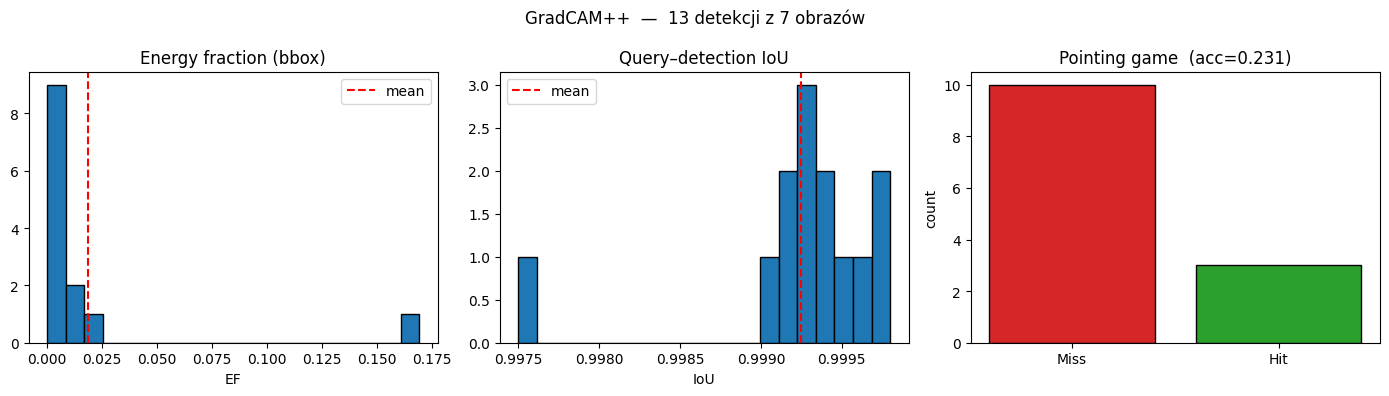

✓ Wykres zapisany do /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_gradcampp/gradcampp_metrics_summary.png


In [37]:
if len(ok_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(ok_df["energy_fraction"], bins=20, edgecolor="black")
    axes[0].set_title("Energy fraction (bbox)")
    axes[0].set_xlabel("EF")
    axes[0].axvline(ok_df["energy_fraction"].mean(), color="red", linestyle="--", label="mean")
    axes[0].legend()

    axes[1].hist(ok_df["matched_iou"], bins=20, edgecolor="black")
    axes[1].set_title("Query–detection IoU")
    axes[1].set_xlabel("IoU")
    axes[1].axvline(ok_df["matched_iou"].mean(), color="red", linestyle="--", label="mean")
    axes[1].legend()

    pg_counts = ok_df["pointing_game"].value_counts().sort_index()
    axes[2].bar(["Miss", "Hit"], [pg_counts.get(0, 0), pg_counts.get(1, 0)],
                color=["#d62728", "#2ca02c"], edgecolor="black")
    axes[2].set_title(f"Pointing game  (acc={ok_df['pointing_game'].mean():.3f})")
    axes[2].set_ylabel("count")

    fig.suptitle(f"GradCAM++  —  {len(ok_df)} detekcji z {ok_df['image'].nunique()} obrazów")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "gradcampp_metrics_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Wykres zapisany do {OUTPUT_DIR / 'gradcampp_metrics_summary.png'}")